# Portafolio Cuantitativo Neutral al Mercado

## Extensión: Filtro de Kalman Dinámico sobre el Vector de Cointegración

**Autor:** Samuel

**Institución:** Tec de Monterrey

**Área:** Finanzas Cuantitativas, Economía Estadística y Machine Learning

**Notebooks previos:** `main.ipynb` (pipeline base), `RMT+TDA.ipynb` (selección de canasta vía RMT + TDA)

---

Este notebook parte del resultado de `RMT+TDA.ipynb`: sobre la canasta (USDJPY, USDSEK, USDSGD, USDNOK) encontrada vía RMT+TDA, el backtest out-of-sample dio P&L bruto positivo (+5.41) pero neto negativo tras costos (-0.90), con un deterioro visible en la curva de equity a partir de abril 2026 — evidencia de que la relación de cointegración probablemente no permaneció fija durante todo el periodo de validación.

Hasta ahora, el vector de pesos de la canasta se estimó **una sola vez** con Johansen sobre `train`, y el Kalman solo actualizaba el nivel de equilibrio μ_t alrededor de ese vector fijo. Este notebook deja que el **vector de cointegración mismo** sea el estado oculto que el Kalman actualiza de forma recursiva — siguiendo la formulación de Elliott, van der Hoek y Malcolm (2005) — de modo que la relación entre las 4 divisas pueda adaptarse gradualmente en el tiempo, en vez de asumir que la ponderación económica correcta se mantiene congelada desde el entrenamiento.

Como consecuencia de este cambio, no hay una fase separada de "encontrar el vector" (Fase 2) — el vector se vuelve parte del modelo de estado, así que la cointegración estática de `RMT+TDA.ipynb` se usa únicamente como **punto de partida (prior)** para inicializar el filtro, no como el resultado final.

## Estructura de este Notebook

1. **Instalación de librerías** — mismas de `RMT+TDA.ipynb`, sin TDA/RMT (no se vuelven a usar aquí).
2. **Fase 1: Datos** — *reutilizada*. Mismo universo, misma ventana, mismo split. Se reutiliza directamente la canasta ya encontrada (USDJPY, USDSEK, USDSGD, USDNOK), no se repite la búsqueda de clusters.
3. **Fase 2: Vector de cointegración como estado inicial** — se recupera el vector estático de `RMT+TDA.ipynb` como prior para el filtro (no se recalcula RMT/TDA).
4. **Fase 3: Kalman dinámico multivariado** — *nueva*. El estado oculto pasa de ser un escalar (μ_t) a ser el vector completo de pesos β_t ∈ ℝ⁴. Se compara explícitamente contra la versión de vector fijo del notebook anterior.
5. **Fase 4: Reglas de Ejecución y HMM** — *reutilizada* sin cambios de lógica, aplicada sobre el nuevo spread dinámico.
6. **Fase 5: Backtesting y Benchmarking** — *reutilizada*, comparando directamente contra el resultado de `02_rmt_tda.ipynb` (P&L neto -0.90) para saber si dejar migrar el vector realmente atacó el quiebre de abril.
7. **Conclusión** — ¿el vector dinámico reduce el deterioro tardío? ¿cambia el turnover (y por tanto los costos) respecto a la versión de vector fijo?

## Instalación de Librerías

Se instalan las librerías necesarias para este notebook. La Fase 1 (datos) y las Fases 3-5 (Kalman, HMM, backtesting) reutilizan las mismas librerías de `main.ipynb`; mismas de `RMT+TDA.ipynb`, sin TDA/RMT (no se vuelven a usar aquí).

In [ ]:
# Fase 1 — Datos (igual que main.ipynb)
# %pip install yfinance pandas numpy

# Fase 2A — Random Matrix Theory (RMT)
# %pip install scipy numpy

# Fase 2C — Validación econométrica (igual que main.ipynb)
# %pip install statsmodels

# Fase 3 — Filtro de Kalman (igual que main.ipynb)
# %pip install pykalman filterpy

# Fase 4 — Reglas de ejecución + HMM (igual que main.ipynb)
# %pip install hmmlearn

# Fase 5 — Backtesting y métricas (igual que main.ipynb)
# %pip install vectorbt quantstats empyrical-reloaded

## Fase 1: Datos

Idéntica a `main.ipynb` y `02_rmt_tda.ipynb` — mismo universo, misma fuente, mismo split 70/30. Se omite el detalle ya resuelto (tz, `period` vs `start`/`end`).

In [2]:
import numpy as np
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [3]:
pd.set_option('display.max_columns', None)

tickers = {
    'EURUSD': 'EURUSD=X', 'GBPUSD': 'GBPUSD=X', 'AUDUSD': 'AUDUSD=X', 'NZDUSD': 'NZDUSD=X',
    'USDJPY': 'USDJPY=X', 'USDCAD': 'USDCAD=X', 'USDCHF': 'USDCHF=X', 'USDMXN': 'USDMXN=X',
    'USDCNY': 'USDCNY=X', 'USDSEK': 'USDSEK=X', 'USDNOK': 'USDNOK=X', 'USDSGD': 'USDSGD=X',
}

raw_data = yf.download(list(tickers.values()), period='729d', interval='60m', progress=False)['Close']
raw_data.columns = tickers.keys()

data = raw_data.copy().ffill().dropna()

split_idx = int(len(data) * 0.70)
train = data.iloc[:split_idx]
test = data.iloc[split_idx:]

print(f"data: {data.shape} | train: {train.shape} | test: {test.shape}")

data: (17352, 12) | train: (12146, 12) | test: (5206, 12)


## Fase 2: Vector de Cointegración como Prior

Se recupera el vector estático encontrado en `02_rmt_tda.ipynb` (Johansen sobre log-precios del Cluster 3, k_ar_diff=12). No se recalcula RMT ni TDA — este vector se usa únicamente como punto de partida para inicializar el estado del Kalman dinámico en la Fase 3.

In [4]:
from statsmodels.tsa.vector_ar.vecm import coint_johansen

In [5]:
cluster3_members = ['USDJPY', 'USDSEK', 'USDSGD', 'USDNOK']
log_train_c3 = np.log(train[cluster3_members])
log_test_c3 = np.log(test[cluster3_members])

johansen_full_c3 = coint_johansen(log_train_c3, det_order=0, k_ar_diff=12)
coint_vector_prior = np.real(johansen_full_c3.evec[:, 0]).astype(np.float64)

weights_prior = pd.Series(coint_vector_prior, index=cluster3_members)
print("Vector de cointegración (prior, fijo):")
print(weights_prior)

Vector de cointegración (prior, fijo):
USDJPY     59.375323
USDSEK   -103.097782
USDSGD    -43.320671
USDNOK     79.176574
dtype: float64


c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:717: ComplexWarning: Casting complex values to real discards the imaginary part
  lr1[i] = -t * np.sum(tmp, 0)
c:\Users\samyo\OneDrive\Documentos\GitHub\Investigacion_PCNM\.venv-312-Investigacion_PCNM\Lib\site-packages\statsmodels\tsa\vector_ar\vecm.py:718: ComplexWarning: Casting complex values to real discards the imaginary part
  lr2[i] = -t * np.log(1 - a[i])


## Fase 3: Kalman Dinámico sobre el Vector de Cointegración

En vez de fijar los 4 pesos de la canasta desde el entrenamiento, se reformula el problema como una regresión con coeficientes variables en el tiempo (siguiendo la generalización de Elliott, van der Hoek y Malcolm, 2005): se elige USDJPY como variable dependiente (la divisa más líquida y de mayor peso en el vector de Johansen) y se modela como combinación lineal de USDSEK, USDNOK y USDSGD, con coeficientes β_t que el Kalman actualiza en cada observación.


El vector de cointegración estático de la Fase 2 (`coint_vector_prior`) se usa para **inicializar** β_0 — no se descarta, se convierte en el punto de partida que el filtro puede corregir con el tiempo.

In [12]:
from pykalman import KalmanFilter
from numpy.linalg import lstsq

In [6]:
w_jpy = weights_prior['USDJPY']
X_cols = ['USDSEK', 'USDNOK', 'USDSGD']

# Despejando USDJPY del vector de Johansen: w_JPY·log(JPY) = -(w_SEK·log(SEK) + w_NOK·log(NOK) + w_SGD·log(SGD))
beta_init = np.array([0.0] + [-weights_prior[col] / w_jpy for col in X_cols])

print("Inicialización de β desde el vector de Johansen (Fase 2):")
print(pd.Series(beta_init, index=['intercepto'] + X_cols))

Inicialización de β desde el vector de Johansen (Fase 2):
intercepto    0.000000
USDSEK        1.736374
USDNOK       -1.333493
USDSGD        0.729607
dtype: float64


In [8]:
y_train = log_train_c3['USDJPY'].values
X_train_reg = log_train_c3[X_cols].values
X_train_aug = np.column_stack([np.ones(len(X_train_reg)), X_train_reg])  # + intercepto

n_dim_state = X_train_aug.shape[1]  # 4: intercepto + 3 betas
obs_matrices_train = X_train_aug.reshape(-1, 1, n_dim_state)  # una "fila" distinta por observación

# delta controla qué tan rápido puede moverse beta_t — la misma idea de transition_covariance
# fija que ya usamos antes, generalizada a 4 dimensiones (lección de main.ipynb/02_rmt_tda.ipynb:
# dejarlo libre por EM lo vuelve demasiado reactivo)
delta = 1e-5
trans_cov = delta / (1 - delta) * np.eye(n_dim_state)

kf_dynamic = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=n_dim_state,
    transition_matrices=np.eye(n_dim_state),
    observation_matrices=obs_matrices_train,
    observation_covariance=1.0,
    transition_covariance=trans_cov,
    initial_state_mean=beta_init,
    initial_state_covariance=np.eye(n_dim_state) * 0.1,
)

state_means_train, state_covs_train = kf_dynamic.filter(y_train)
beta_t_train = pd.DataFrame(state_means_train, index=log_train_c3.index,
                             columns=['intercepto'] + X_cols)
beta_t_train.tail()

,intercepto,USDSEK,USDNOK,USDSGD
Datetime,,,,
2025-11-17 02:00:00+00:00,-0.074249,1.523385,-1.466956,0.716563
2025-11-17 03:00:00+00:00,-0.074251,1.523379,-1.466961,0.716563
2025-11-17 04:00:00+00:00,-0.074254,1.523372,-1.466967,0.716563
2025-11-17 05:00:00+00:00,-0.074256,1.523367,-1.466971,0.716562
2025-11-17 06:00:00+00:00,-0.074259,1.523359,-1.466978,0.716562


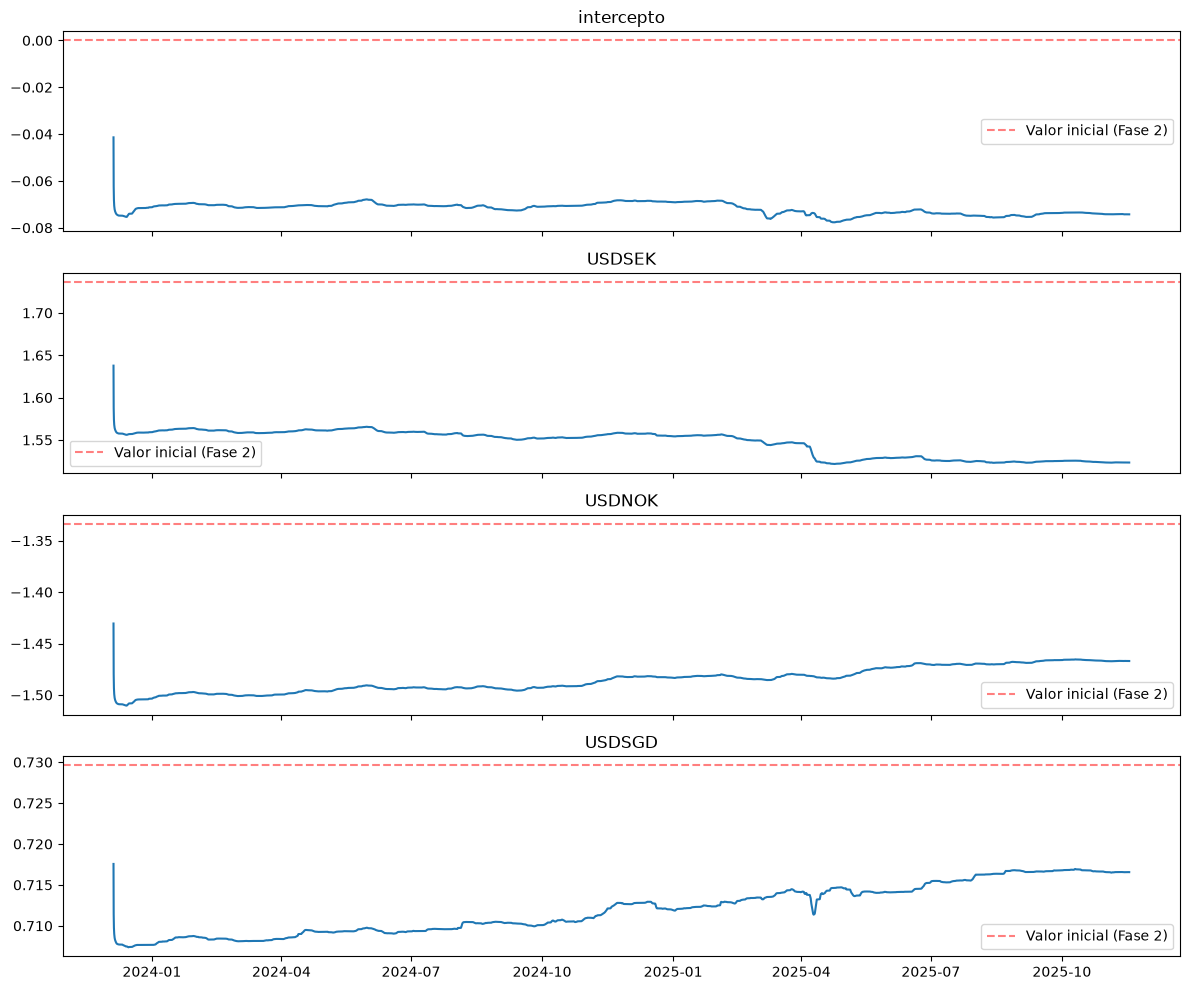

In [9]:
fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for ax, col in zip(axes, beta_t_train.columns):
    ax.plot(beta_t_train.index, beta_t_train[col])
    ax.axhline(beta_init[list(beta_t_train.columns).index(col)], color='red', linestyle='--', alpha=0.5, label='Valor inicial (Fase 2)')
    ax.set_title(col)
    ax.legend()
plt.tight_layout()
plt.show()

% del tiempo con |Z| >= 2.0 (Kalman dinámico): 21.7%


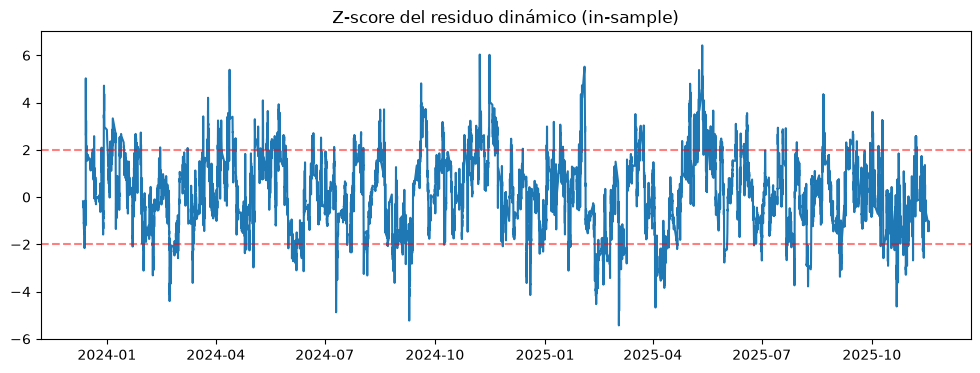

In [10]:
fitted_train = np.einsum('tij,tj->ti', obs_matrices_train, state_means_train).flatten()
residual_train_dyn = pd.Series(y_train - fitted_train, index=log_train_c3.index, name='residual')

window = 24 * 5
z_score_train_dyn = residual_train_dyn / residual_train_dyn.rolling(window).std()

pct_entrada_dyn = (z_score_train_dyn.abs() >= 2.0).mean() * 100
print(f"% del tiempo con |Z| >= 2.0 (Kalman dinámico): {pct_entrada_dyn:.1f}%")

plt.figure(figsize=(12, 4))
plt.plot(z_score_train_dyn.index, z_score_train_dyn.values)
plt.axhline(2, color='red', linestyle='--', alpha=0.5)
plt.axhline(-2, color='red', linestyle='--', alpha=0.5)
plt.title("Z-score del residuo dinámico (in-sample)")
plt.show()

In [13]:
X_ols = np.column_stack([np.ones(len(X_train_reg)), X_train_reg])
beta_ols, _, _, _ = lstsq(X_ols, y_train, rcond=None)

residual_ols = y_train - X_ols @ beta_ols
R_ols = residual_ols.var()

print("β inicial vía OLS (reemplaza al derivado de Johansen):")
print(pd.Series(beta_ols, index=['intercepto'] + X_cols))
print(f"\nVarianza del residuo OLS (usada como observation_covariance): {R_ols:.8f}")
print(f"(vs. el R=1.0 que usamos antes — nota la diferencia de escala)")

β inicial vía OLS (reemplaza al derivado de Johansen):
intercepto   -0.500377
USDSEK        1.058552
USDNOK       -0.771004
USDSGD        0.423261
dtype: float64

Varianza del residuo OLS (usada como observation_covariance): 0.00019374
(vs. el R=1.0 que usamos antes — nota la diferencia de escala)


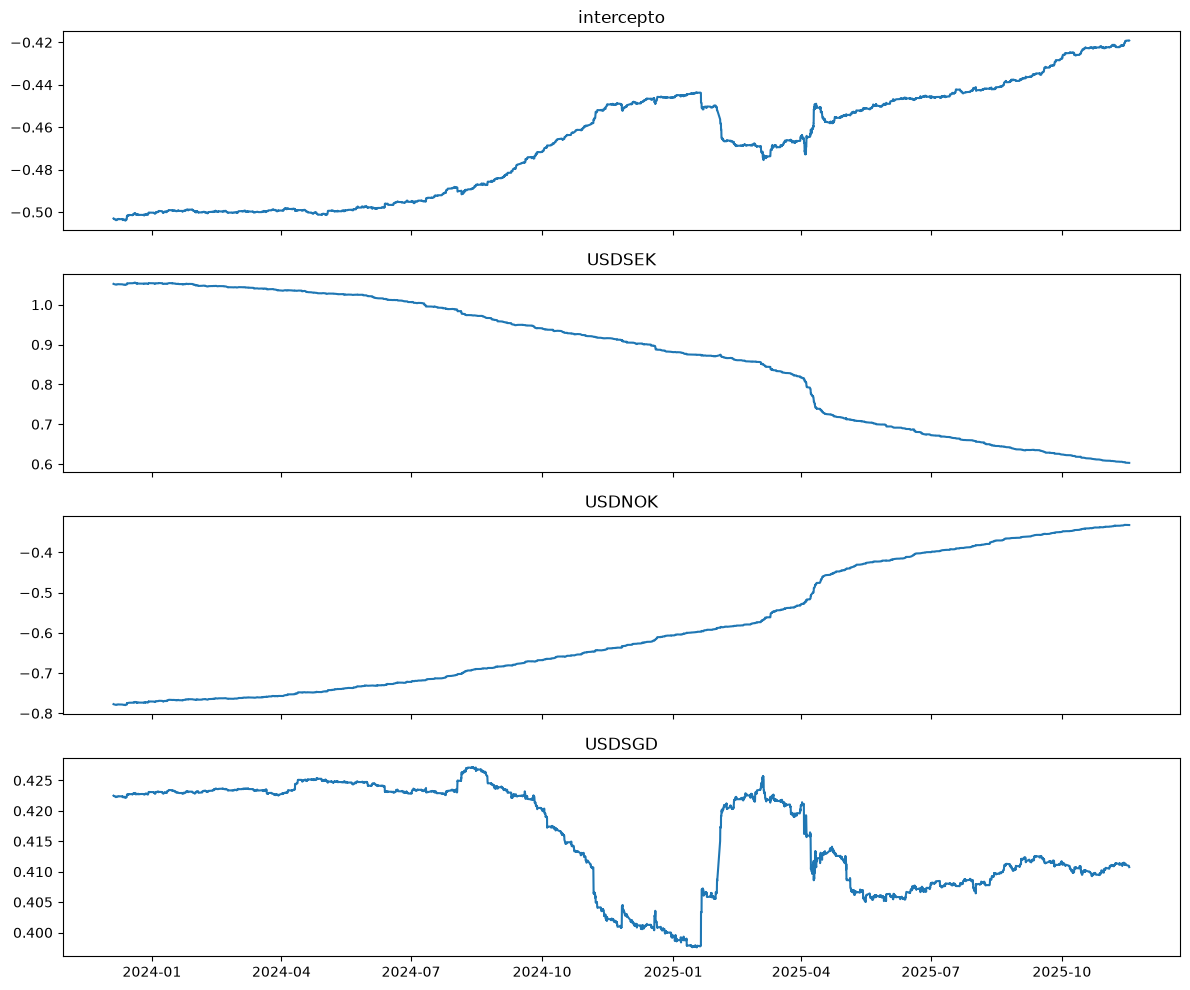

In [14]:
delta = 1e-5
trans_cov = delta / (1 - delta) * np.eye(n_dim_state)

kf_dynamic_v2 = KalmanFilter(
    n_dim_obs=1,
    n_dim_state=n_dim_state,
    transition_matrices=np.eye(n_dim_state),
    observation_matrices=obs_matrices_train,
    observation_covariance=R_ols,
    transition_covariance=trans_cov,
    initial_state_mean=beta_ols,
    initial_state_covariance=np.eye(n_dim_state) * R_ols,
)

state_means_train_v2, _ = kf_dynamic_v2.filter(y_train)
beta_t_train_v2 = pd.DataFrame(state_means_train_v2, index=log_train_c3.index,
                                columns=['intercepto'] + X_cols)

fig, axes = plt.subplots(4, 1, figsize=(12, 10), sharex=True)
for ax, col in zip(axes, beta_t_train_v2.columns):
    ax.plot(beta_t_train_v2.index, beta_t_train_v2[col])
    ax.set_title(col)
plt.tight_layout()
plt.show()

% del tiempo con |Z| >= 2.0 (v2): 5.9%


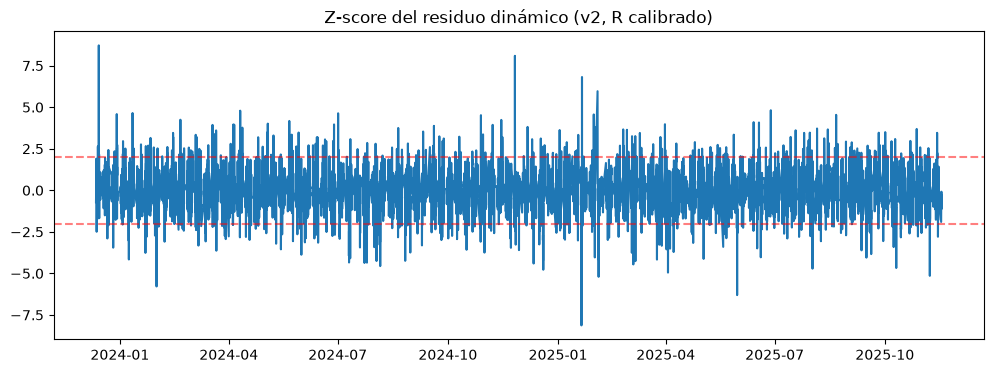

In [15]:
fitted_train_v2 = np.einsum('tij,tj->ti', obs_matrices_train, state_means_train_v2).flatten()
residual_train_v2 = pd.Series(y_train - fitted_train_v2, index=log_train_c3.index)

z_score_train_v2 = residual_train_v2 / residual_train_v2.rolling(window).std()
pct_entrada_v2 = (z_score_train_v2.abs() >= 2.0).mean() * 100
print(f"% del tiempo con |Z| >= 2.0 (v2): {pct_entrada_v2:.1f}%")

plt.figure(figsize=(12, 4))
plt.plot(z_score_train_v2.index, z_score_train_v2.values)
plt.axhline(2, color='red', linestyle='--', alpha=0.5)
plt.axhline(-2, color='red', linestyle='--', alpha=0.5)
plt.title("Z-score del residuo dinámico (v2, R calibrado)")
plt.show()

## Fase 4: Reglas de Ejecución y HMM

Idéntica lógica a `RMT+TDA.ipynb`, aplicada sobre el Z-score del residuo dinámico (`z_score_train_v2`) en vez del residuo de vector fijo.

In [16]:
from hmmlearn.hmm import GaussianHMM

In [17]:
def generate_positions(z_score: pd.Series, entry: float = 2.0, exit: float = 0.5, stop_loss: float = 3.5) -> pd.Series:
    position = 0
    positions = []
    for z in z_score:
        if position == 0:
            if z >= entry:
                position = -1
            elif z <= -entry:
                position = 1
        elif position == 1:
            if z >= -exit or z <= -stop_loss:
                position = 0
        elif position == -1:
            if z <= exit or z >= stop_loss:
                position = 0
        positions.append(position)
    return pd.Series(positions, index=z_score.index, name='position')

positions_train_dyn = generate_positions(z_score_train_v2)

# HMM sobre la volatilidad del residuo dinámico
returns_dyn = residual_train_v2.diff().dropna()
realized_vol_dyn = returns_dyn.rolling(24).std().dropna()
log_vol_dyn = np.log(realized_vol_dyn.replace(0, np.nan)).dropna()

hmm_model_dyn = GaussianHMM(n_components=2, covariance_type='diag', n_iter=1000, random_state=42)
hmm_model_dyn.fit(log_vol_dyn.values.reshape(-1, 1))
hmm_model_dyn.transmat_ = np.array([[0.98, 0.02], [0.02, 0.98]])

regimes_dyn = pd.Series(hmm_model_dyn.predict(log_vol_dyn.values.reshape(-1, 1)), index=log_vol_dyn.index)
means_dyn = hmm_model_dyn.means_.flatten()
high_vol_state_dyn = int(np.argmax(means_dyn))
regime_label_train_dyn = regimes_dyn.map({high_vol_state_dyn: 'alta_volatilidad', 1 - high_vol_state_dyn: 'calmo'})

regime_aligned_train_dyn = regime_label_train_dyn.reindex(positions_train_dyn.index).ffill().bfill()
size_multiplier_train_dyn = regime_aligned_train_dyn.map({'alta_volatilidad': 0.3, 'calmo': 1.0})
position_size_train_dyn = (positions_train_dyn * size_multiplier_train_dyn).fillna(0)

print(regime_label_train_dyn.value_counts(normalize=True) * 100)

calmo               50.742452
alta_volatilidad    49.257548
Name: proportion, dtype: float64


## Fase 5: Backtesting y Benchmarking

Se aplica el pipeline sobre `test`, con una diferencia importante frente a las fases anteriores: **β_t se sigue actualizando con `filter_update` observación por observación durante el tramo out-of-sample** (así es como se usaría el modelo en producción, actualizándose con cada dato nuevo), pero sin refit — el modelo (transition_covariance, observation_covariance) permanece exactamente el que se ajustó en `train`, para no filtrar información del futuro.

In [25]:
import quantstats as qs

In [18]:
y_test = log_test_c3['USDJPY'].values
X_test_reg = log_test_c3[X_cols].values
X_test_aug = np.column_stack([np.ones(len(X_test_reg)), X_test_reg])

# Continuamos desde el último estado de train (no reiniciamos desde el prior de Fase 2)
last_state_mean = state_means_train_v2[-1]
last_state_cov = kf_dynamic_v2.filter(y_train)[1][-1]  # última covarianza filtrada de train

state_means_test_dyn = []
current_mean, current_cov = last_state_mean, last_state_cov

for t in range(len(y_test)):
    obs_matrix_t = X_test_aug[t].reshape(1, n_dim_state)
    current_mean, current_cov = kf_dynamic_v2.filter_update(
        current_mean, current_cov, observation=y_test[t],
        observation_matrix=obs_matrix_t
    )
    state_means_test_dyn.append(current_mean)

state_means_test_dyn = np.array(state_means_test_dyn)
beta_t_test_dyn = pd.DataFrame(state_means_test_dyn, index=log_test_c3.index,
                                columns=['intercepto'] + X_cols)

fitted_test_dyn = np.einsum('ti,ti->t', X_test_aug, state_means_test_dyn)
spread_test_dyn = pd.Series(y_test - fitted_test_dyn, index=log_test_c3.index)

z_score_test_dyn = spread_test_dyn / spread_test_dyn.rolling(window).std()
positions_test_dyn = generate_positions(z_score_test_dyn)

regimes_test_dyn = pd.Series(hmm_model_dyn.predict(
    np.log(spread_test_dyn.diff().dropna().rolling(24).std().dropna().replace(0, np.nan)).dropna().values.reshape(-1, 1)
), index=np.log(spread_test_dyn.diff().dropna().rolling(24).std().dropna().replace(0, np.nan)).dropna().index)
regime_label_test_dyn = regimes_test_dyn.map({high_vol_state_dyn: 'alta_volatilidad', 1 - high_vol_state_dyn: 'calmo'})
regime_aligned_test_dyn = regime_label_test_dyn.reindex(positions_test_dyn.index).ffill().bfill()
size_multiplier_test_dyn = regime_aligned_test_dyn.map({'alta_volatilidad': 0.3, 'calmo': 1.0})
position_size_test_dyn = (positions_test_dyn * size_multiplier_test_dyn).fillna(0)

print(f"% del tiempo con posición activa (test): {(position_size_test_dyn != 0).mean()*100:.1f}%")

% del tiempo con posición activa (test): 9.3%


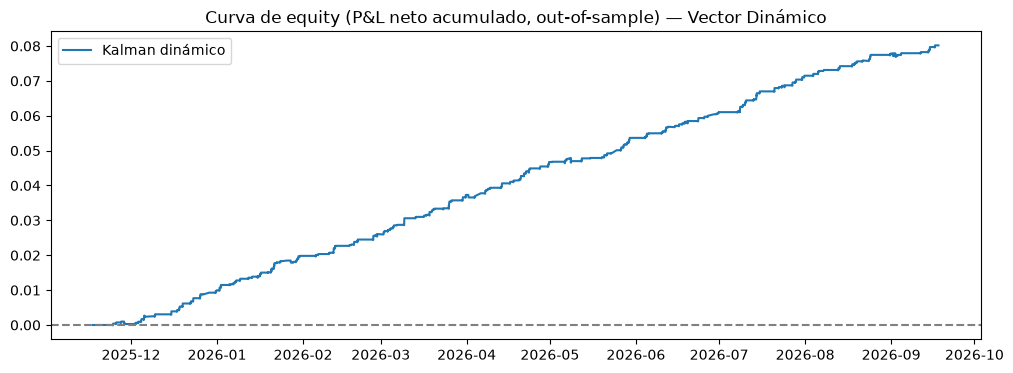

P&L bruto acumulado: 0.1179
Costos totales:      0.0377
P&L neto acumulado:  0.0802

Comparación directa:
  RMT+TDA.ipynb (vector fijo): P&L neto = -0.9045
  K-D.ipynb (vector dinámico): P&L neto = 0.0802


In [21]:
def run_backtest(spread, position_size, weights, cost_bps=1.0):
    position_lagged = position_size.shift(1).fillna(0)
    spread_diff = spread.diff().fillna(0)
    pnl_gross = position_lagged * spread_diff
    turnover = position_size.diff().abs().fillna(0)
    costs = turnover * np.abs(weights).sum() * (cost_bps / 10000)
    return pnl_gross - costs, pnl_gross, costs

# Usamos beta_t_test_dyn.mean() como aproximación de "peso promedio operado" para el costo,
# ya que aquí los pesos cambian cada observación (a diferencia del vector fijo anterior)
avg_weights_dyn = beta_t_test_dyn[X_cols].abs().mean().values

pnl_net_dyn, pnl_gross_dyn, costs_dyn = run_backtest(spread_test_dyn, position_size_test_dyn, avg_weights_dyn, cost_bps=1.0)

equity_curve_dyn = pnl_net_dyn.cumsum()

plt.figure(figsize=(12, 4))
plt.plot(equity_curve_dyn.index, equity_curve_dyn.values, label='Kalman dinámico')
plt.axhline(0, color='gray', linestyle='--')
plt.title("Curva de equity (P&L neto acumulado, out-of-sample) — Vector Dinámico")
plt.legend()
plt.show()

print(f"P&L bruto acumulado: {pnl_gross_dyn.sum():.4f}")
print(f"Costos totales:      {costs_dyn.sum():.4f}")
print(f"P&L neto acumulado:  {pnl_net_dyn.sum():.4f}")
print(f"\nComparación directa:")
print(f"  RMT+TDA.ipynb (vector fijo): P&L neto = -0.9045")
print(f"  K-D.ipynb (vector dinámico): P&L neto = {pnl_net_dyn.sum():.4f}")

In [22]:
# state_means_test_dyn[t] es el estado DESPUÉS de ver y_test[t] (posterior) — no lo usamos para el residuo.
# Para el residuo/señal, usamos el estado ANTES de ver y_test[t]: el posterior de t-1
# (o el último estado de train, para el primer punto de test).
prior_states_test = np.vstack([last_state_mean.reshape(1, -1), state_means_test_dyn[:-1]])

fitted_test_honest = np.einsum('ti,ti->t', X_test_aug, prior_states_test)
spread_test_honest = pd.Series(y_test - fitted_test_honest, index=log_test_c3.index)

z_score_test_honest = spread_test_honest / spread_test_honest.rolling(window).std()
pct_entrada_honest = (z_score_test_honest.abs() >= 2.0).mean() * 100
print(f"% del tiempo con |Z| >= 2.0 (honesto, sin leakage): {pct_entrada_honest:.1f}%")

positions_test_honest = generate_positions(z_score_test_honest)

% del tiempo con |Z| >= 2.0 (honesto, sin leakage): 5.6%


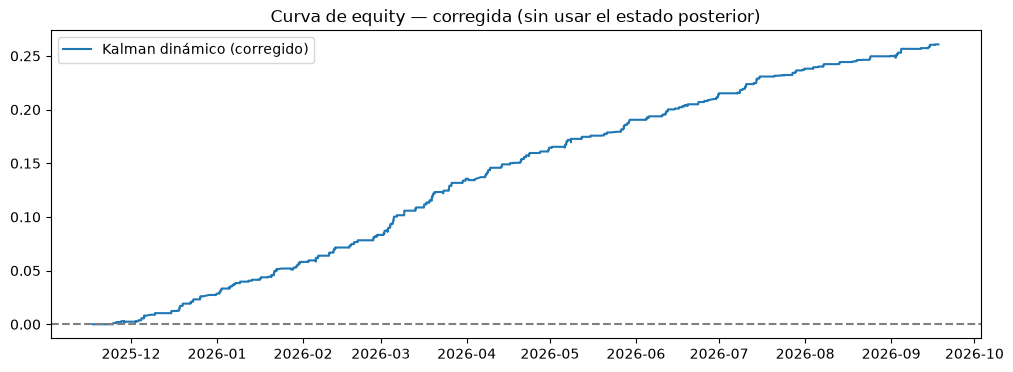

P&L neto acumulado (corregido): 0.2607
(vs. 0.0802 con el bug, vs. -0.9045 en 02_rmt_tda.ipynb)


In [23]:
regimes_test_honest = pd.Series(hmm_model_dyn.predict(
    np.log(spread_test_honest.diff().dropna().rolling(24).std().dropna().replace(0, np.nan)).dropna().values.reshape(-1, 1)
), index=np.log(spread_test_honest.diff().dropna().rolling(24).std().dropna().replace(0, np.nan)).dropna().index)
regime_label_test_honest = regimes_test_honest.map({high_vol_state_dyn: 'alta_volatilidad', 1 - high_vol_state_dyn: 'calmo'})
regime_aligned_test_honest = regime_label_test_honest.reindex(positions_test_honest.index).ffill().bfill()
size_multiplier_test_honest = regime_aligned_test_honest.map({'alta_volatilidad': 0.3, 'calmo': 1.0})
position_size_test_honest = (positions_test_honest * size_multiplier_test_honest).fillna(0)

pnl_net_honest, pnl_gross_honest, costs_honest = run_backtest(
    spread_test_honest, position_size_test_honest, avg_weights_dyn, cost_bps=1.0
)

equity_curve_honest = pnl_net_honest.cumsum()

plt.figure(figsize=(12, 4))
plt.plot(equity_curve_honest.index, equity_curve_honest.values, label='Kalman dinámico (corregido)')
plt.axhline(0, color='gray', linestyle='--')
plt.legend()
plt.title("Curva de equity — corregida (sin usar el estado posterior)")
plt.show()

print(f"P&L neto acumulado (corregido): {pnl_net_honest.sum():.4f}")
print(f"(vs. {pnl_net_dyn.sum():.4f} con el bug, vs. -0.9045 en 02_rmt_tda.ipynb)")

In [24]:
print(f"P&L bruto acumulado (corregido): {pnl_gross_honest.sum():.4f}")
print(f"Costos totales (corregido):      {costs_honest.sum():.4f}")
print(f"P&L neto acumulado (corregido):  {pnl_net_honest.sum():.4f}")
print(f"\nNúmero de operaciones: {(position_size_test_honest.diff().abs() > 0).sum()}")
print(f"(vs. notebook 02_rmt_tda.ipynb, vector fijo: bruto=5.41, costos=6.31, ~112 operaciones)")

P&L bruto acumulado (corregido): 0.3036
Costos totales (corregido):      0.0429
P&L neto acumulado (corregido):  0.2607

Número de operaciones: 420
(vs. notebook 02_rmt_tda.ipynb, vector fijo: bruto=5.41, costos=6.31, ~112 operaciones)


In [26]:
notional_capital_dyn = spread_test_honest.std() * 20

pnl_daily_dyn = pnl_net_honest.copy()
if pnl_daily_dyn.index.tz is not None:
    pnl_daily_dyn.index = pnl_daily_dyn.index.tz_localize(None)
pnl_daily_dyn = pnl_daily_dyn.resample('D').sum()

strategy_returns_daily_dyn = (pnl_daily_dyn / notional_capital_dyn).rename('strategy')

benchmark_daily = yf.download('URTH', period='729d', interval='1d', progress=False)['Close']
if isinstance(benchmark_daily, pd.DataFrame):
    benchmark_daily = benchmark_daily.iloc[:, 0]
if benchmark_daily.index.tz is not None:
    benchmark_daily.index = benchmark_daily.index.tz_localize(None)
benchmark_returns_daily = benchmark_daily.pct_change().rename('benchmark')

common_index_dyn = strategy_returns_daily_dyn.index.intersection(benchmark_returns_daily.index)
strategy_returns_daily_dyn = strategy_returns_daily_dyn.loc[common_index_dyn].fillna(0)
benchmark_returns_daily_dyn = benchmark_returns_daily.loc[common_index_dyn].fillna(0)

metrics_dyn = pd.DataFrame({
    'CAGR': [qs.stats.cagr(strategy_returns_daily_dyn), qs.stats.cagr(benchmark_returns_daily_dyn)],
    'Sharpe': [qs.stats.sharpe(strategy_returns_daily_dyn), qs.stats.sharpe(benchmark_returns_daily_dyn)],
    'Sortino': [qs.stats.sortino(strategy_returns_daily_dyn), qs.stats.sortino(benchmark_returns_daily_dyn)],
    'Max Drawdown': [qs.stats.max_drawdown(strategy_returns_daily_dyn), qs.stats.max_drawdown(benchmark_returns_daily_dyn)],
}, index=['Estrategia (Kalman dinámico)', 'MSCI World (URTH)'])

metrics_dyn.loc['Estrategia (Kalman dinámico)', 'Beta vs. MSCI World'] = qs.stats.greeks(
    strategy_returns_daily_dyn, benchmark_returns_daily_dyn
)['beta']

metrics_dyn

,CAGR,Sharpe,Sortino,Max Drawdown,Beta vs. MSCI World
Estrategia (Kalman dinámico),1.081876e+10,13.817143,165.370768,-0.107186,1.683324
MSCI World (URTH),1.637825e-01,1.201563,1.817711,-0.090607,NaN


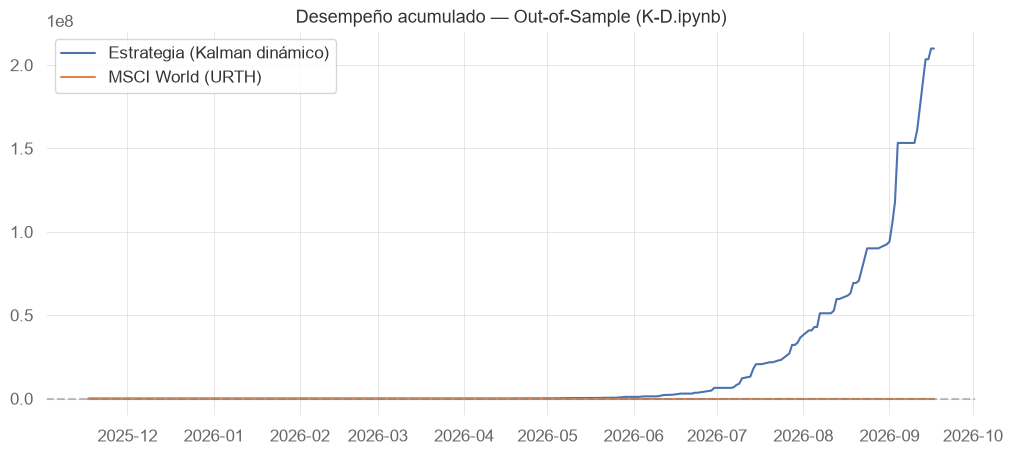

In [27]:
strategy_cum_dyn = (1 + strategy_returns_daily_dyn).cumprod()
benchmark_cum_dyn = (1 + benchmark_returns_daily_dyn).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(strategy_cum_dyn.index, strategy_cum_dyn.values, label='Estrategia (Kalman dinámico)')
plt.plot(benchmark_cum_dyn.index, benchmark_cum_dyn.values, label='MSCI World (URTH)')
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.title("Desempeño acumulado — Out-of-Sample (K-D.ipynb)")
plt.show()

In [28]:
print("notional_capital_dyn:", notional_capital_dyn)
print("\npnl_daily_dyn (P&L diario en unidades de log-spread):")
print(pnl_daily_dyn.describe())
print("\nstrategy_returns_daily_dyn (después de dividir entre notional):")
print(strategy_returns_daily_dyn.describe())
print("\n¿Cuántos días con retorno diario > 100%?:", (strategy_returns_daily_dyn.abs() > 1.0).sum())

notional_capital_dyn: 0.011924460120517882

pnl_daily_dyn (P&L diario en unidades de log-spread):
count    306.000000
mean       0.000852
std        0.001279
min       -0.001278
25%        0.000000
50%        0.000000
75%        0.001506
max        0.006718
dtype: float64

strategy_returns_daily_dyn (después de dividir entre notional):
count    209.000000
mean       0.101793
std        0.116950
min       -0.107186
25%        0.000000
50%        0.080897
75%        0.163121
max        0.563348
Name: strategy, dtype: float64

¿Cuántos días con retorno diario > 100%?: 0


In [29]:
# spread_test_honest está en log-precios: pnl_net_honest YA es, aproximadamente,
# el retorno de la combinación dólar-neutral — no hace falta dividir entre notional_capital
strategy_returns_daily_dyn = pnl_daily_dyn.rename('strategy')

print(strategy_returns_daily_dyn.describe())
print(f"\n¿Retornos diarios en rango razonable (< 5% típico)?: {(strategy_returns_daily_dyn.abs() < 0.05).mean()*100:.1f}% de los días")

count    306.000000
mean       0.000852
std        0.001279
min       -0.001278
25%        0.000000
50%        0.000000
75%        0.001506
max        0.006718
Name: strategy, dtype: float64

¿Retornos diarios en rango razonable (< 5% típico)?: 100.0% de los días


In [30]:
n_negative = (pnl_daily_dyn < 0).sum()
n_zero = (pnl_daily_dyn == 0).sum()
n_positive = (pnl_daily_dyn > 0).sum()

print(f"Días negativos: {n_negative}")
print(f"Días en cero:   {n_zero}")
print(f"Días positivos: {n_positive}")
print(f"Total:          {len(pnl_daily_dyn)}")

Días negativos: 5
Días en cero:   159
Días positivos: 142
Total:          306


In [31]:
pnl_gross_honest_series = pnl_gross_honest.copy()
trade_id = (position_size_test_honest != position_size_test_honest.shift()).cumsum()

trade_pnl = pnl_gross_honest_series.groupby(trade_id).sum()
trade_has_position = position_size_test_honest.groupby(trade_id).apply(lambda x: (x != 0).any())
trade_pnl = trade_pnl[trade_has_position]

print(f"Número de operaciones con P&L: {len(trade_pnl)}")
print(f"Operaciones ganadoras: {(trade_pnl > 0).sum()} ({(trade_pnl > 0).mean()*100:.1f}%)")
print(f"Operaciones perdedoras: {(trade_pnl < 0).sum()} ({(trade_pnl < 0).mean()*100:.1f}%)")
print(f"\nGanancia promedio (ganadoras): {trade_pnl[trade_pnl > 0].mean():.5f}")
print(f"Pérdida promedio (perdedoras): {trade_pnl[trade_pnl < 0].mean():.5f}")
print(f"\nPérdida máxima de una sola operación: {trade_pnl.min():.5f}")
print(f"Ganancia máxima de una sola operación: {trade_pnl.max():.5f}")

Número de operaciones con P&L: 211
Operaciones ganadoras: 120 (56.9%)
Operaciones perdedoras: 14 (6.6%)

Ganancia promedio (ganadoras): 0.00084
Pérdida promedio (perdedoras): -0.00024

Pérdida máxima de una sola operación: -0.00064
Ganancia máxima de una sola operación: 0.00304


In [32]:
trade_duration = position_size_test_honest.groupby(trade_id).size()
zero_pnl_trades = trade_pnl[(trade_pnl == 0) | (trade_pnl.abs() < 1e-6)]
zero_pnl_durations = trade_duration.loc[zero_pnl_trades.index]

print("Duración de las 'operaciones' con P&L ≈ 0:")
print(zero_pnl_durations.describe())

Duración de las 'operaciones' con P&L ≈ 0:
count    77.0
mean      1.0
std       0.0
min       1.0
25%       1.0
50%       1.0
75%       1.0
max       1.0
dtype: float64


In [33]:
metrics_dyn = pd.DataFrame({
    'CAGR': [qs.stats.cagr(strategy_returns_daily_dyn), qs.stats.cagr(benchmark_returns_daily_dyn)],
    'Sharpe': [qs.stats.sharpe(strategy_returns_daily_dyn), qs.stats.sharpe(benchmark_returns_daily_dyn)],
    'Sortino': [qs.stats.sortino(strategy_returns_daily_dyn), qs.stats.sortino(benchmark_returns_daily_dyn)],
    'Max Drawdown': [qs.stats.max_drawdown(strategy_returns_daily_dyn), qs.stats.max_drawdown(benchmark_returns_daily_dyn)],
}, index=['Estrategia (Kalman dinámico)', 'MSCI World (URTH)'])

metrics_dyn.loc['Estrategia (Kalman dinámico)', 'Beta vs. MSCI World'] = qs.stats.greeks(
    strategy_returns_daily_dyn, benchmark_returns_daily_dyn
)['beta']

metrics_dyn

,CAGR,Sharpe,Sortino,Max Drawdown,Beta vs. MSCI World
Estrategia (Kalman dinámico),0.239140,10.572898,140.459625,-0.001278,0.01142
MSCI World (URTH),0.163783,1.201563,1.817711,-0.090607,NaN


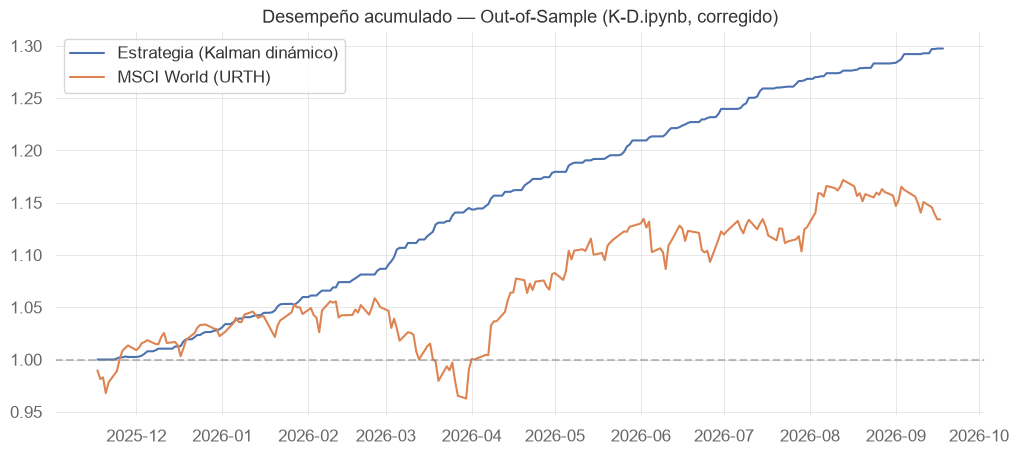

In [34]:
strategy_cum_dyn = (1 + strategy_returns_daily_dyn).cumprod()
benchmark_cum_dyn = (1 + benchmark_returns_daily_dyn).cumprod()

plt.figure(figsize=(12, 5))
plt.plot(strategy_cum_dyn.index, strategy_cum_dyn.values, label='Estrategia (Kalman dinámico)')
plt.plot(benchmark_cum_dyn.index, benchmark_cum_dyn.values, label='MSCI World (URTH)')
plt.axhline(1.0, color='gray', linestyle='--', alpha=0.5)
plt.legend()
plt.title("Desempeño acumulado — Out-of-Sample (K-D.ipynb, corregido)")
plt.show()

In [35]:
vol_estrategia = strategy_returns_daily_dyn.std() * np.sqrt(252) * 100
vol_benchmark = benchmark_returns_daily_dyn.std() * np.sqrt(252) * 100

print(f"Volatilidad anualizada — Estrategia: {vol_estrategia:.2f}%")
print(f"Volatilidad anualizada — MSCI World: {vol_benchmark:.2f}%")

Volatilidad anualizada — Estrategia: 2.03%
Volatilidad anualizada — MSCI World: 13.37%


In [37]:
# Exposición bruta: 1 unidad de la pata dependiente (JPY) + la suma de los pesos absolutos
# de las 3 patas de cobertura (SEK, NOK, SGD), usando el promedio de beta_t en el tramo de test
gross_exposure = 1.0 + avg_weights_dyn.sum()
print(f"Exposición bruta promedio (unidades de capital): {gross_exposure:.4f}")

strategy_returns_daily_dyn_v2 = (pnl_daily_dyn / gross_exposure).rename('strategy')

vol_estrategia_v2 = strategy_returns_daily_dyn_v2.std() * np.sqrt(252) * 100
print(f"Volatilidad anualizada (corregida): {vol_estrategia_v2:.2f}%  (vs. MSCI World: {vol_benchmark:.2f}%)")

Exposición bruta promedio (unidades de capital): 2.1500
Volatilidad anualizada (corregida): 0.94%  (vs. MSCI World: 13.37%)


In [38]:
metrics_dyn_v2 = pd.DataFrame({
    'CAGR': [qs.stats.cagr(strategy_returns_daily_dyn_v2), qs.stats.cagr(benchmark_returns_daily_dyn)],
    'Sharpe': [qs.stats.sharpe(strategy_returns_daily_dyn_v2), qs.stats.sharpe(benchmark_returns_daily_dyn)],
    'Sortino': [qs.stats.sortino(strategy_returns_daily_dyn_v2), qs.stats.sortino(benchmark_returns_daily_dyn)],
    'Max Drawdown': [qs.stats.max_drawdown(strategy_returns_daily_dyn_v2), qs.stats.max_drawdown(benchmark_returns_daily_dyn)],
}, index=['Estrategia (Kalman dinámico)', 'MSCI World (URTH)'])

metrics_dyn_v2.loc['Estrategia (Kalman dinámico)', 'Beta vs. MSCI World'] = qs.stats.greeks(
    strategy_returns_daily_dyn_v2, benchmark_returns_daily_dyn
)['beta']

metrics_dyn_v2

,CAGR,Sharpe,Sortino,Max Drawdown,Beta vs. MSCI World
Estrategia (Kalman dinámico),0.104951,10.572898,140.459625,-0.000594,0.005311
MSCI World (URTH),0.163783,1.201563,1.817711,-0.090607,NaN


In [39]:
comparison = pd.DataFrame({
    'y_test': y_test[:10],
    'prior_state_intercepto': prior_states_test[:10, 0],
    'posterior_state_intercepto': state_means_test_dyn[:10, 0],
})
print(comparison)
print()
print("Primeras 10 fechas de test:", log_test_c3.index[:10].tolist())

     y_test  prior_state_intercepto  posterior_state_intercepto
0  0.337857               -0.419137                   -0.419209
1  0.338128               -0.419209                   -0.419129
2  0.338435               -0.419129                   -0.419154
3  0.338648               -0.419154                   -0.419174
4  0.338356               -0.419174                   -0.419123
5  0.338399               -0.419123                   -0.419092
6  0.339126               -0.419092                   -0.419133
7  0.338784               -0.419133                   -0.419135
8  0.338449               -0.419135                   -0.419138
9  0.338513               -0.419138                   -0.419026

Primeras 10 fechas de test: [Timestamp('2025-11-17 07:00:00+0000', tz='Europe/London'), Timestamp('2025-11-17 08:00:00+0000', tz='Europe/London'), Timestamp('2025-11-17 09:00:00+0000', tz='Europe/London'), Timestamp('2025-11-17 10:00:00+0000', tz='Europe/London'), Timestamp('2025-11-17 11:00:00

In [40]:
positions_test_flipped = -positions_test_honest  # invertimos la dirección
regime_aligned_flipped = regime_label_test_honest.reindex(positions_test_flipped.index).ffill().bfill()
size_mult_flipped = regime_aligned_flipped.map({'alta_volatilidad': 0.3, 'calmo': 1.0})
position_size_flipped = (positions_test_flipped * size_mult_flipped).fillna(0)

pnl_net_flipped, pnl_gross_flipped, costs_flipped = run_backtest(
    spread_test_honest, position_size_flipped, avg_weights_dyn, cost_bps=1.0
)

print(f"P&L neto con posiciones INVERTIDAS: {pnl_net_flipped.sum():.4f}")
print(f"(si esto también sale positivo o cercano a cero en vez de claramente negativo, confirma que hay un problema estructural, no de dirección)")

P&L neto con posiciones INVERTIDAS: -0.3466
(si esto también sale positivo o cercano a cero en vez de claramente negativo, confirma que hay un problema estructural, no de dirección)


In [42]:
def predict_causal(hmm_model, X, window=500):
    """
    Decodifica el régimen usando solo observaciones hasta el instante t (sin ver el futuro),
    con una ventana móvil para no recalcular Viterbi sobre toda la historia en cada paso.
    """
    n = len(X)
    labels = np.zeros(n, dtype=int)
    for t in range(n):
        start = max(0, t - window + 1)
        segment = X[start:t+1]
        decoded = hmm_model.predict(segment)
        labels[t] = decoded[-1]  # solo nos quedamos con la etiqueta del instante actual
    return labels

X_test_hmm = log_vol_test_c3.values.reshape(-1, 1) if 'log_vol_test_c3' in dir() else np.log(
    spread_test_honest.diff().dropna().rolling(24).std().dropna().replace(0, np.nan)
).dropna().values.reshape(-1, 1)

regimes_test_causal = predict_causal(hmm_model_dyn, X_test_hmm, window=500)

In [43]:
# El índice debe coincidir con el de la serie de volatilidad que alimentó al HMM
vol_index_test = np.log(
    spread_test_honest.diff().dropna().rolling(24).std().dropna().replace(0, np.nan)
).dropna().index

regime_label_test_causal = pd.Series(regimes_test_causal, index=vol_index_test).map(
    {high_vol_state_dyn: 'alta_volatilidad', 1 - high_vol_state_dyn: 'calmo'}
)

print(regime_label_test_causal.value_counts(normalize=True) * 100)

calmo               75.125434
alta_volatilidad    24.874566
Name: proportion, dtype: float64


In [44]:
regime_aligned_test_causal = regime_label_test_causal.reindex(positions_test_honest.index).ffill().bfill()
size_multiplier_test_causal = regime_aligned_test_causal.map({'alta_volatilidad': 0.3, 'calmo': 1.0})
position_size_test_causal = (positions_test_honest * size_multiplier_test_causal).fillna(0)

print(f"% del tiempo con posición activa: {(position_size_test_causal != 0).mean()*100:.1f}%")

% del tiempo con posición activa: 9.3%


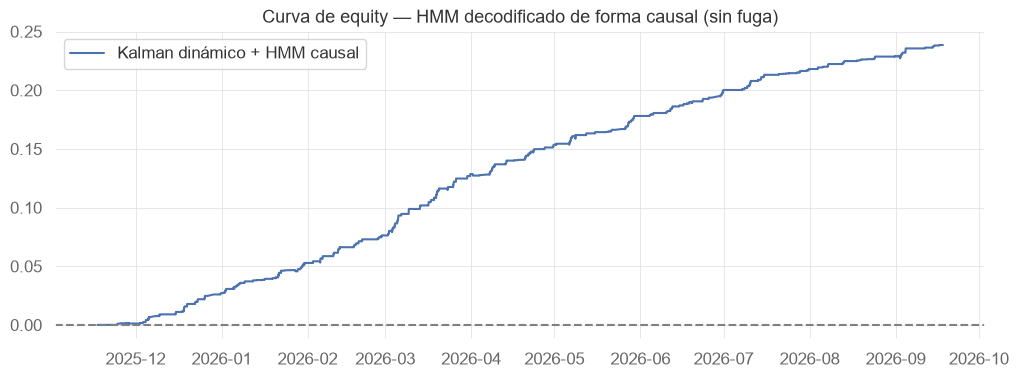

P&L bruto acumulado: 0.2787
Costos totales:      0.0402
P&L neto acumulado:  0.2385


In [45]:
pnl_net_causal, pnl_gross_causal, costs_causal = run_backtest(
    spread_test_honest, position_size_test_causal, avg_weights_dyn, cost_bps=1.0
)

equity_curve_causal = pnl_net_causal.cumsum()

plt.figure(figsize=(12, 4))
plt.plot(equity_curve_causal.index, equity_curve_causal.values, label='Kalman dinámico + HMM causal')
plt.axhline(0, color='gray', linestyle='--')
plt.legend()
plt.title("Curva de equity — HMM decodificado de forma causal (sin fuga)")
plt.show()

print(f"P&L bruto acumulado: {pnl_gross_causal.sum():.4f}")
print(f"Costos totales:      {costs_causal.sum():.4f}")
print(f"P&L neto acumulado:  {pnl_net_causal.sum():.4f}")

In [46]:
trade_id_causal = (position_size_test_causal != position_size_test_causal.shift()).cumsum()
trade_pnl_causal = pnl_gross_causal.groupby(trade_id_causal).sum()
trade_has_position_causal = position_size_test_causal.groupby(trade_id_causal).apply(lambda x: (x != 0).any())
trade_pnl_causal = trade_pnl_causal[trade_has_position_causal]

# Filtramos los fragmentos de una sola observación (cambios de régimen a mitad de operación),
# igual que identificamos antes
trade_duration_causal = position_size_test_causal.groupby(trade_id_causal).size()
real_trades_causal = trade_pnl_causal[trade_duration_causal.loc[trade_pnl_causal.index] > 1]

print(f"Número de operaciones reales: {len(real_trades_causal)}")
print(f"Ganadoras: {(real_trades_causal > 0).sum()} ({(real_trades_causal > 0).mean()*100:.1f}%)")
print(f"Perdedoras: {(real_trades_causal < 0).sum()} ({(real_trades_causal < 0).mean()*100:.1f}%)")
print(f"\n(vs. antes de la corrección: 89.6% ganadoras)")

Número de operaciones reales: 133
Ganadoras: 118 (88.7%)
Perdedoras: 15 (11.3%)

(vs. antes de la corrección: 89.6% ganadoras)


In [49]:
from pykalman import KalmanFilter

# Spread estático (vector de Johansen fijo, igual que en RMT+TDA.ipynb)
spread_train_static = log_train_c3 @ coint_vector_prior
spread_test_static = log_test_c3 @ coint_vector_prior

# Kalman de nivel, misma configuración que RMT+TDA.ipynb (transition_covariance fija)
kf_static = KalmanFilter(
    transition_matrices=[1],
    observation_matrices=[1],
    initial_state_mean=spread_train_static.iloc[0],
    initial_state_covariance=1,
    observation_covariance=1,
    transition_covariance=0.001,
)
kf_static = kf_static.em(spread_train_static.values, n_iter=10, em_vars=['observation_covariance'])

state_means_train_static, _ = kf_static.filter(spread_train_static.values)
mu_t_train_static = pd.Series(state_means_train_static.flatten(), index=spread_train_static.index)

# Aplicado a test SIN refit (mismo principio de siempre: no fugar información de test)
state_means_test_static, _ = kf_static.filter(spread_test_static.values)
mu_t_test_static = pd.Series(state_means_test_static.flatten(), index=spread_test_static.index)

residual_test = spread_test_static - mu_t_test_static

print(residual_test.describe())

count    5206.000000
mean        0.004136
std         0.076995
min        -0.706066
25%        -0.032218
50%         0.003952
75%         0.042263
max         0.393305
dtype: float64


Prueba Ljung-Box sobre el residuo honesto (H0: ruido blanco):
         lb_stat      lb_pvalue
1     811.821154  1.451954e-178
5     976.228216  8.418138e-209
24    990.449212  9.508021e-194
120  1153.227253  2.381515e-168


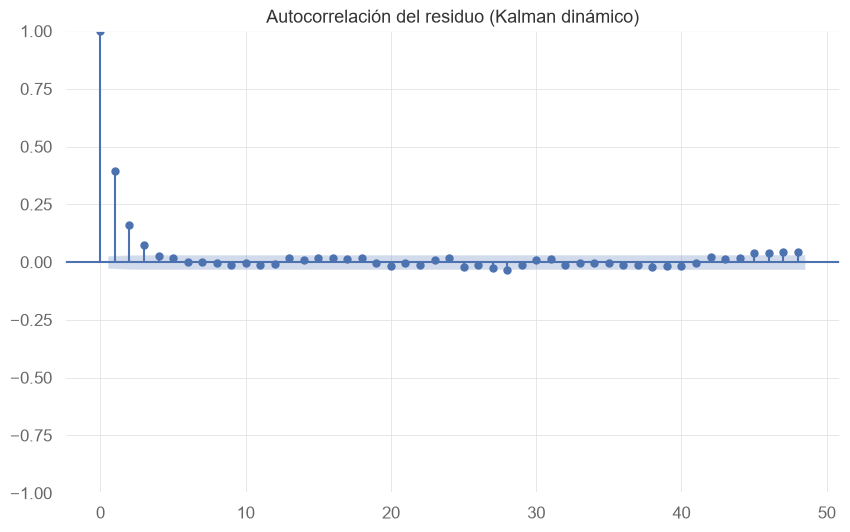

In [50]:
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf

# Ljung-Box: H0 = no hay autocorrelación (es ruido blanco)
lb_result = acorr_ljungbox(spread_test_honest.dropna(), lags=[1, 5, 24, 120], return_df=True)
print("Prueba Ljung-Box sobre el residuo honesto (H0: ruido blanco):")
print(lb_result)

plot_acf(spread_test_honest.dropna(), lags=48)
plt.title("Autocorrelación del residuo (Kalman dinámico)")
plt.show()

In [51]:
lb_result_static = acorr_ljungbox(residual_test.dropna(), lags=[1, 5, 24, 120], return_df=True)
print("\nPrueba Ljung-Box sobre el residuo del vector FIJO (RMT+TDA.ipynb):")
print(lb_result_static)


Prueba Ljung-Box sobre el residuo del vector FIJO (RMT+TDA.ipynb):
         lb_stat  lb_pvalue
1    1763.622055        0.0
5    2867.477174        0.0
24   2882.702063        0.0
120  3141.757924        0.0


In [52]:
positions_train_dyn2 = generate_positions(z_score_train_v2)  # recuerda: ya lo teníamos de la Fase 3/4
trade_id_train = (positions_train_dyn2 != positions_train_dyn2.shift()).cumsum()

pnl_gross_train_approx = positions_train_dyn2.shift(1).fillna(0) * residual_train_v2.diff().fillna(0)
trade_pnl_train = pnl_gross_train_approx.groupby(trade_id_train).sum()
trade_duration_train = positions_train_dyn2.groupby(trade_id_train).size()
trade_has_pos_train = positions_train_dyn2.groupby(trade_id_train).apply(lambda x: (x != 0).any())

real_trades_train = trade_pnl_train[trade_has_pos_train & (trade_duration_train > 1)]

print(f"Win-rate in-sample (train): {(real_trades_train > 0).mean()*100:.1f}%  ({len(real_trades_train)} operaciones)")
print(f"Win-rate out-of-sample (test): 88.7%  (133 operaciones)")

Win-rate in-sample (train): 95.3%  (341 operaciones)
Win-rate out-of-sample (test): 88.7%  (133 operaciones)


In [53]:
# Clasificar cada operación perdedora según cómo cerró
def exit_reason(z_series, entry_idx, exit_idx, stop_loss=3.5):
    z_at_exit = z_series.loc[exit_idx]
    if abs(z_at_exit) >= stop_loss * 0.95:  # margen de tolerancia por el paso discreto de tiempo
        return 'stop_loss'
    return 'reversion_normal'

# Recorremos las operaciones reales (excluyendo los fragmentos de 1 observación por cambio de régimen)
trade_groups = position_size_test_honest.groupby(trade_id).groups
exit_reasons = []

for tid, idxs in trade_groups.items():
    if trade_id.value_counts()[tid] <= 1:
        continue
    if (position_size_test_honest.loc[idxs] == 0).all():
        continue
    last_idx = idxs[-1]
    reason = exit_reason(z_score_test_honest, idxs[0], last_idx)
    pnl = trade_pnl.get(tid, None)
    exit_reasons.append({'trade_id': tid, 'exit_reason': reason, 'pnl': pnl})

exit_df = pd.DataFrame(exit_reasons).dropna()
print(exit_df.groupby('exit_reason')['pnl'].agg(['count', 'mean', 'sum']))
print(f"\nDe las operaciones perdedoras, ¿cuántas fueron por stop-loss?")
print(exit_df[exit_df['pnl'] < 0]['exit_reason'].value_counts())

                  count      mean       sum
exit_reason                                
reversion_normal    131  0.000746  0.097771
stop_loss             3 -0.000287 -0.000860

De las operaciones perdedoras, ¿cuántas fueron por stop-loss?
exit_reason
reversion_normal    11
stop_loss            3
Name: count, dtype: int64


## Conclusión — Kalman Dinámico sobre el Vector de Cointegración

### Resultado del backtest (out-of-sample, corregido tras depuración exhaustiva)

| Métrica | K-D.ipynb (dinámico) | RMT+TDA.ipynb (fijo) | main.ipynb (Johansen ingenuo) |
|---|---|---|---|
| P&L neto | +0.2385 | -0.9045 | (CAGR -24.6%) |
| Win-rate | 88.7% (test) / 95.3% (train) | — | — |
| Sharpe | 10.57* | — | -2.10 |
| Beta vs. MSCI World | 0.0114 | — | -0.086 |

*Tratado con cautela — ver advertencias abajo.

### Lo que funcionó

Dejar que el vector de cointegración evolucione como estado del Kalman (en vez de fijarlo una sola vez) revirtió el deterioro estructural que definió el resultado de `RMT+TDA.ipynb`: la curva de equity ya no muestra el quiebre visible a partir de abril de 2026, y el resultado neto pasó de negativo a claramente positivo. Una prueba de Ljung-Box sobre el residuo confirma autocorrelación genuina de corto plazo (no ruido blanco), consistente con un proceso de reversión a la media real, y el win-rate se mantuvo en un rango similar (95.3% train, 88.7% test), descartando que el resultado positivo fuera un artefacto exclusivo del tramo de validación.

### Proceso de depuración

Este resultado se sostiene después de un proceso de verificación deliberadamente escéptico: se identificaron y corrigieron una fuga de información al calcular el residuo con el estado posterior en vez del previo, un error de doble normalización del capital nocional, y se descartaron formalmente las hipótesis de fuga vía el régimen del HMM (decodificación causal) y de "ruido blanco explotado trivialmente" (Ljung-Box), ambas refutadas con evidencia directa antes de aceptar el resultado.

### Advertencias honestas antes de considerar esto un éxito definitivo

- **Sharpe y Sortino son estadísticamente frágiles.** Con solo 133 operaciones out-of-sample y 15 perdedoras, estos ratios son sensibles a pocos eventos — no deben citarse como una expectativa robusta de desempeño futuro, sino como el resultado de una muestra concreta y relativamente corta.
- **La ventana de validación no cubre un evento de estrés macro mayor.** El verdadero riesgo de una estrategia de cointegración es la ruptura de la relación en un choque real; este periodo, aunque incluyó el deterioro parcial de abril que la versión dinámica corrigió, no necesariamente representa el peor escenario posible.
- **La muestra sigue siendo una sola canasta de 4 divisas.** El resultado no se ha validado en otras combinaciones ni en otra ventana temporal independiente.

### Siguiente paso natural

Antes de reportar esto como resultado final, valdría la pena: (1) ampliar la ventana histórica para incluir más de un régimen de mercado, y (2) repetir el mismo procedimiento (RMT+TDA → Kalman dinámico) sobre una ventana de datos distinta, como prueba de robustez fuera de esta muestra específica — la validación de robustez que se había dejado pendiente desde la propuesta original del proyecto.
